Epoch 1/15


c:\Users\MSI\anaconda3\envs\my-project\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1095/1095 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0035 - val_loss: 1.8482e-04
Epoch 2/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.8446e-04 - val_loss: 1.7074e-04
Epoch 3/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.4224e-04 - val_loss: 2.0988e-04
Epoch 4/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 1.2545e-04 - val_loss: 1.4841e-04
Epoch 5/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.2150e-04 - val_loss: 1.3446e-04
Epoch 6/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 1.0799e-04 - val_loss: 9.4224e-05
Epoch 7/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.1941e-04 - val_loss: 1.1952e-04
Epoch 8/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 1.1354e-04 - val_loss: 1.1109e-04
Epoch 9/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 1.0807e-04 - val_loss: 1.0635e-04
Epoch 10/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 1.0626e-04 - val_loss: 2.5165e-04
Epoch 11/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

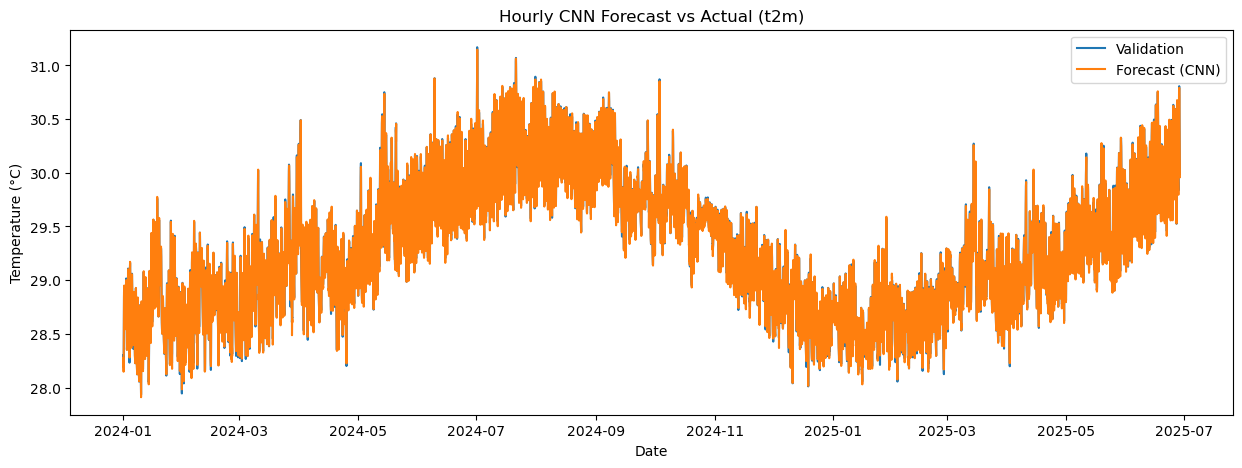

MAE: 0.027102619218001705
RMSE: 0.03982105918865884


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten

# Load data
df = pd.read_csv("../../data/processed/sfax_weather_features.csv", parse_dates=['valid_time'])
df = df.set_index('valid_time')

# Scaling
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df[['t2m']])

# Create supervised sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 24
X, y = create_sequences(df_scaled, seq_length)

# Train/Validation split
train_size = df.loc[:'2023-12-31'].shape[0] - seq_length
X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:], y[train_size:]

# CNN Model
model_cnn = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(seq_length, 1)),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1)
])

model_cnn.compile(optimizer='adam', loss='mse')

# Training
history_cnn = model_cnn.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_val, y_val)
)

# Prediction
y_pred_scaled_cnn = model_cnn.predict(X_val)
y_pred_cnn = scaler.inverse_transform(y_pred_scaled_cnn)
y_val_true = scaler.inverse_transform(y_val)

# Plot
val_index = df.index[train_size + seq_length:]
plt.figure(figsize=(15,5))
plt.plot(val_index, y_val_true, label='Validation')
plt.plot(val_index, y_pred_cnn, label='Forecast (CNN)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('Hourly CNN Forecast vs Actual (t2m)')
plt.legend()
plt.show()

# Evaluation
mae_cnn = mean_absolute_error(y_val_true, y_pred_cnn)
rmse_cnn = np.sqrt(mean_squared_error(y_val_true, y_pred_cnn))

print(f"MAE: {mae_cnn}")
print(f"RMSE: {rmse_cnn}")
